## 1. 서포트 벡터 머신 (SVM, Support Vector Machine)

- **문제 유형**: 분류
- **목표**: 손글씨 숫자 데이터(`digits`)를 보고 각 숫자 클래스를 예측
- **모델 특징**:
  - 클래스 간의 경계를 최대한 크게 만드는 초평면을 찾는 모델
  - 선형 커널, RBF 커널 등 다양한 커널을 사용할 수 있음
  - 고차원 데이터에서도 강한 성능을 보이는 경우가 많음
  - SVM은 경계를 잘 나누는 것보다 경계를 얼마나 여유 있게 나누는가(마진)를 더 중요하게 보는 모델

**데이터를 가장 잘 구분하는 결정 경계를 찾는 모델**

### 평가 지표
- **Accuracy**: 전체 데이터 중 정답을 맞춘 비율
- **Confusion Matrix**: 실제 값과 예측 값의 관계를 통해 어떤 클래스에서 오분류가 발생했는지 확인
- **Classification Report**: Precision, Recall, F1-score를 종합적으로 확인

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_digits

# 데이터 로드
data = load_digits()
X = data.data
y = data.target

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# SVM 모델 생성 (선형 커널)
model = SVC(kernel='linear', random_state=42)

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9796296296296296

Confusion Matrix:
 [[53  0  0  0  0  0  0  0  0  0]
 [ 0 49  0  0  0  0  0  0  1  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 52  0  1  0  0  0  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  0  0  0  0 64  0  1  0  1]
 [ 0  0  0  0  0  0 53  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  0  1  0  0  1  1 56]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.98      0.98        50
           2       0.98      1.00      0.99        47
           3       1.00      0.96      0.98        54
           4       0.98      0.98      0.98        60
           5       0.97      0.97      0.97        66
           6       1.00      1.00      1.00        53
           7       0.96      0.98      0.97        55
           8       0.95      0.98      0.97        43
           9       0.97      0.95      0.96        59


## 2. 랜덤 포레스트 분류 (Random Forest Classifier)

- **문제 유형**: 분류
- **목표**: 손글씨 숫자 데이터를 분류
- **모델 특징**:
  - 여러 개의 결정트리를 만든 뒤 결과를 종합하는 앙상블 모델
  - 하나의 트리보다 일반적으로 더 안정적인 성능을 보임
  - 과적합을 줄이는 데 도움이 됨

**여러 개의 결정트리를 결합하여 더 안정적으로 예측하는 분류 모델**

### 평가 지표
- **Accuracy**: 전체 데이터 중 정답을 맞춘 비율
- **Confusion Matrix**: 클래스별 오분류 패턴 확인 가능
- **Classification Report**: Precision, Recall, F1-score 확인 가능

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_digits

# 데이터셋 로드 (손글씨 데이터셋 사용)
data = load_digits()
X = data.data  # 특성 데이터
y = data.target  # 목표 변수 (클래스 레이블)

# 데이터를 학습용 및 테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 랜덤 포레스트 모델 학습 (트리 개수: 100)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 모델 평가
accuracy = accuracy_score(y_test, y_pred)  # 정확도 계산
cm = confusion_matrix(y_test, y_pred)  # 오차 행렬 계산
report = classification_report(y_test, y_pred)  # 정밀도, 재현율, F1-score 계산

# 결과 출력
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

Accuracy: 97.59%

Confusion Matrix:
[[52  0  0  0  1  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  0 52  0  0  0  0  2  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  1 63  1  0  0  1]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  2  0  0  0  0  0  0 41  0]
 [ 0  0  0  1  0  1  0  1  0 56]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      1.00      0.98        50
           2       1.00      1.00      1.00        47
           3       0.98      0.96      0.97        54
           4       0.97      1.00      0.98        60
           5       0.97      0.95      0.96        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.95      0.95      0.95        43
           9       0.97      0.95      0.96        59

    accuracy 

## 3. K-평균 군집화 (K-Means Clustering)

- **문제 유형**: 군집화 (비지도 학습)
- **목표**: 정답 레이블 없이 데이터의 유사성을 기준으로 그룹을 나누기
- **모델 특징**:
  - 데이터를 K개의 군집으로 나누는 대표적인 클러스터링 알고리즘
  - 각 군집의 중심점(centroid)을 기준으로 가장 가까운 군집에 할당
  - 레이블 없이 데이터 구조를 탐색할 때 자주 사용됨

**비슷한 데이터끼리 자동으로 묶어주는 군집화 모델**

### 평가 포인트
- **비지도 학습**이므로 Accuracy 같은 지도학습용 지표를 바로 사용하지 않음
- 대신 **클러스터가 어떻게 나뉘는지 시각화**해서 확인
- 새로운 데이터가 어느 군집에 속하는지도 예측 가능

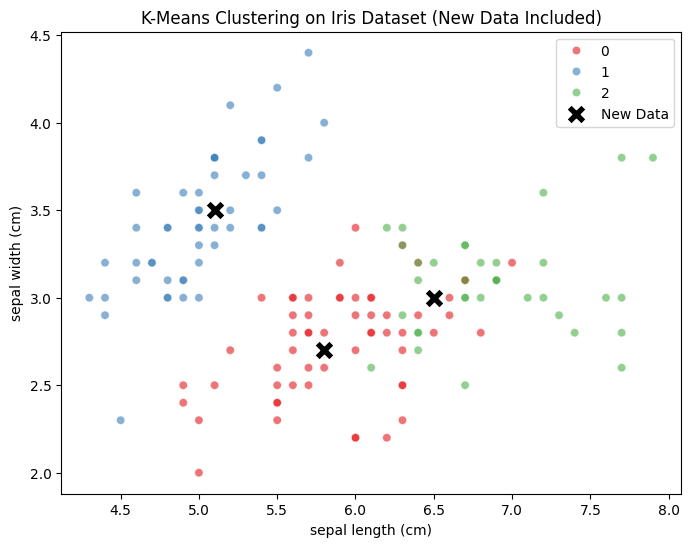

New Data Point 1: Cluster 1
New Data Point 2: Cluster 2
New Data Point 3: Cluster 0


In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Iris 데이터셋 로드
data = load_iris()
X = data.data  # 특성 데이터

# K-평균 클러스터링 적용 (K=3, Iris 데이터셋에 3개의 종이 존재하므로) 
# (모르면 여러개로 나눠야 함 -> 여기서는 정답이 이미 3개로 나누는 데이터) 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)  # 클러스터 할당

# 데이터프레임 변환
df = pd.DataFrame(X, columns=data.feature_names)
df['Cluster'] = y_kmeans  # 클러스터 라벨 추가

# ------------- 새로운 데이터 예측 -------------
# 새로운 샘플 데이터 (예시 데이터)
new_data = np.array([[5.1, 3.5, 1.4, 0.2],  # Setosa 범위
                     [6.5, 3.0, 5.2, 2.0],  # Virginica 범위
                     [5.8, 2.7, 4.1, 1.0]]) # Versicolor 범위

# 새로운 데이터의 클러스터 예측
new_clusters = kmeans.predict(new_data)

# 새로운 데이터 추가 (시각화를 위해 첫 번째, 두 번째 특성만 사용)
new_df = pd.DataFrame(new_data, columns=data.feature_names)
new_df['Cluster'] = new_clusters

# ------------- 클러스터링 결과 시각화 -------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['Cluster'],
    palette='Set1',
    alpha=0.6
)
sns.scatterplot(
    x=new_df['sepal length (cm)'],
    y=new_df['sepal width (cm)'],
    color='black',
    marker='X',
    s=200,
    label="New Data"
)

plt.title("K-Means Clustering on Iris Dataset (New Data Included)")
plt.legend()
plt.show()

# 새로운 데이터의 예측된 클러스터 출력
for i, cluster in enumerate(new_clusters):
    print(f"New Data Point {i+1}: Cluster {cluster}")

## 4. 릿지 회귀와 라쏘 회귀 (Ridge / Lasso Regression)

- **문제 유형**: 회귀
- **목표**: 정규화를 사용하여 과적합을 줄인 회귀 모델 비교
- **모델 특징**:
  - **Ridge**: L2 정규화를 사용하여 가중치를 전체적으로 줄임
  - **Lasso**: L1 정규화를 사용하여 일부 가중치를 0으로 만들 수 있음
  - 둘 다 선형 회귀 기반이지만, 규제를 통해 더 안정적인 모델을 만들 수 있음

**정규화를 통해 과적합을 완화하는 회귀 모델**

### 평가 지표
- **MSE (Mean Squared Error)**: 예측값과 실제값 차이를 제곱해 평균낸 값, 작을수록 좋음
- **R² Score**: 모델 설명력, 1에 가까울수록 좋음

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# 데이터셋 로드 (손글씨 숫자 데이터, 0~9 다중 분류)
data = load_digits()
X = data.data  # 특성 데이터 (픽셀 값)
y = data.target  # 목표 변수 (숫자 라벨)

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 로지스틱 회귀는 특성 스케일에 영향을 받으므로 표준화 수행
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # 학습 데이터 기준으로 fit
X_test_scaled = scaler.transform(X_test)         # 테스트 데이터는 transform만

# Logistic Regression
# solver: 가중치를 학습하기 위한 최적화 알고리즘
# saga: L1, L2 모두 지원하며 다중 분류에서도 안정적으로 사용 가능
logistic_clf = LogisticRegression(
    solver='saga',
    max_iter=2000,
    random_state=42
)

logistic_clf.fit(X_train_scaled, y_train)

# 예측
y_pred_basic = logistic_clf.predict(X_test_scaled)

# 평가
accuracy_basic = accuracy_score(y_test, y_pred_basic)
cm_basic = confusion_matrix(y_test, y_pred_basic)
report_basic = classification_report(y_test, y_pred_basic)

print(f"Logistic Regression (Default) - Accuracy: {accuracy_basic * 100:.2f}%")
print("\nConfusion Matrix:")
print(cm_basic)
print("\nClassification Report:")
print(report_basic)

Logistic Regression (Default) - Accuracy: 97.04%

Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  2  0  0  0  0  0  1  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 50  0  1  0  0  2  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  0  0  0  0 63  1  0  0  2]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  0  0  0  0  0  2 57]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.93      0.96        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.89      0.98      0.93        43
           9       0.95      0.97   

## 5. 로지스틱 회귀와 정규화 (Logistic Regression with Regularization)

- **문제 유형**: 분류
- **목표**: 일반 로지스틱 회귀, L1 정규화, L2 정규화 적용 로지스틱 회귀를 비교
- **모델 특징**:
  - **로지스틱 회귀**는 분류 문제를 위한 대표적인 선형 모델
  - **L1 정규화**는 일부 계수를 0으로 만들 수 있어 feature selection 효과가 있음
  - **L2 정규화**는 계수를 전체적으로 줄이며 안정적인 학습에 유리함

**정규화 방식에 따라 분류 모델의 성격이 달라지는 로지스틱 회귀 모델**

### 평가 지표
- **Accuracy**: 전체 데이터 중 정답을 맞춘 비율
- **Confusion Matrix**: 어떤 숫자를 어떤 숫자로 잘못 분류했는지 확인
- **Classification Report**: Precision, Recall, F1-score를 함께 확인

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# 데이터셋 로드 (손글씨 숫자 데이터, 0~9 다중 분류)
data = load_digits()
X = data.data  # 특성 데이터 (픽셀 값)
y = data.target  # 목표 변수 (숫자 라벨)

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 로지스틱 회귀는 특성 스케일에 영향을 받으므로 표준화 수행
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # 학습 데이터 기준으로 fit
X_test_scaled = scaler.transform(X_test)         # 테스트 데이터는 transform만

# Logistic Regression
# solver: 가중치를 학습하기 위한 최적화 알고리즘
# saga: L1, L2 모두 지원하며 다중 분류에서도 안정적으로 사용 가능
logistic_clf = LogisticRegression(
    solver='saga',
    max_iter=2000,
    random_state=42
)

logistic_clf.fit(X_train_scaled, y_train)

# 예측
y_pred_basic = logistic_clf.predict(X_test_scaled)

# 평가
accuracy_basic = accuracy_score(y_test, y_pred_basic)
cm_basic = confusion_matrix(y_test, y_pred_basic)
report_basic = classification_report(y_test, y_pred_basic)

print(f"Logistic Regression (Default) - Accuracy: {accuracy_basic * 100:.2f}%")
print("\nConfusion Matrix:")
print(cm_basic)
print("\nClassification Report:")
print(report_basic)

Logistic Regression (Default) - Accuracy: 97.04%

Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  2  0  0  0  0  0  1  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 50  0  1  0  0  2  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  0  0  0  0 63  1  0  0  2]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  0  0  0  0  0  2 57]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.93      0.96        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.89      0.98      0.93        43
           9       0.95      0.97   

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_digits

# 데이터 로드
data = load_digits()
X = data.data
y = data.target

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# L1 규제 (Lasso Logistic Regression)
# penalty='l1' : 일부 계수를 0으로 만들어 feature selection 효과 발생
# solver='saga' : L1을 지원하는 최적화 알고리즘 (다중 분류에서도 사용 가능)
# max_iter: 최적화를 위해 반복하는 최대 횟수
lasso_clf = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=2000,
    random_state=42
)

lasso_clf.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_clf.predict(X_test_scaled)

accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
cm_lasso = confusion_matrix(y_test, y_pred_lasso)
report_lasso = classification_report(y_test, y_pred_lasso)

# 결과 출력
print(f"Lasso (L1) Logistic Regression - Accuracy: {accuracy_lasso * 100:.2f}%")
print("\nLasso Confusion Matrix:")
print(cm_lasso)
print("\nLasso Classification Report:")
print(report_lasso)

Lasso (L1) Logistic Regression - Accuracy: 97.41%

Lasso Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 48  1  0  0  0  0  0  1  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 51  0  1  0  0  1  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  1  1  0  0 63  1  0  0  0]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  0  0  0  0  0  2 57]]

Lasso Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.96      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.94      0.97        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.91      0.98      0.94        43
           9       0.98

c:\Users\timeo\workspace\ml\ml_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [7]:
# L2 규제 (Ridge Logistic Regression)
# penalty='l2' : 모든 계수를 작게 만들어 과적합 방지
# solver='saga' : L2도 함께 지원 (solver 통일 가능)
# max_iter: 최적화를 위해 반복하는 최대 횟수
ridge_clf = LogisticRegression(
    penalty='l2',
    solver='saga',
    max_iter=2000,
    random_state=42
)

ridge_clf.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_clf.predict(X_test_scaled)

accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
cm_ridge = confusion_matrix(y_test, y_pred_ridge)
report_ridge = classification_report(y_test, y_pred_ridge)

print(f"\nRidge (L2) Logistic Regression - Accuracy: {accuracy_ridge * 100:.2f}%")
print("\nRidge Confusion Matrix:")
print(cm_ridge)
print("\nRidge Classification Report:")
print(report_ridge)


Ridge (L2) Logistic Regression - Accuracy: 97.04%

Ridge Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  2  0  0  0  0  0  1  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 50  0  1  0  0  2  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  0  0  0  0 63  1  0  0  2]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  0  0  0  0  0  2 57]]

Ridge Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.93      0.96        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.89      0.98      0.93        43
           9       0.9

## 6. 스케일링 방식 비교 (MinMaxScaler vs StandardScaler)

- **문제 유형**: 전처리 비교
- **목표**: 같은 모델에 대해 서로 다른 스케일링 방식이 미치는 영향 확인
- **모델 특징**:
  - **Min-Max Scaling**: 값을 0~1 범위로 변환
  - **Standard Scaling**: 평균 0, 표준편차 1 기준으로 표준화
  - 트리 기반 모델은 일반적으로 스케일링 영향이 크지 않지만, 비교 실습으로 의미가 있음

**전처리 방식에 따라 모델 결과가 어떻게 달라지는지 비교하는 실습**

### 평가 지표
- **Accuracy**: 전체 데이터 중 정답을 맞춘 비율
- 두 스케일링 방식의 결과를 비교해 차이를 확인

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits

# 데이터 로드 (손글씨 데이터)
data = load_digits()
X = data.data
y = data.target

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 1. Min-Max Scaling
# 0~1 범위로 스케일링 (거리 기반 모델에서 영향 큼)
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

# 2. Standard Scaling
# 평균 0, 표준편차 1로 변환 (SVM에서 일반적으로 가장 많이 사용)
scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

# 3. SVM 모델 (MinMax)
# SVM은 거리 기반 모델이라 스케일에 매우 민감
svm_minmax = SVC(kernel='rbf', random_state=42)
svm_minmax.fit(X_train_minmax, y_train)
y_pred_minmax = svm_minmax.predict(X_test_minmax)
accuracy_minmax = accuracy_score(y_test, y_pred_minmax)

# 4. SVM 모델 (Standard)
svm_standard = SVC(kernel='rbf', random_state=42)
svm_standard.fit(X_train_standard, y_train)
y_pred_standard = svm_standard.predict(X_test_standard)
accuracy_standard = accuracy_score(y_test, y_pred_standard)

# 결과 출력
print(f"SVM with Min-Max Scaling - Accuracy: {accuracy_minmax * 100:.2f}%")
print(f"SVM with Standard Scaling - Accuracy: {accuracy_standard * 100:.2f}%")

SVM with Min-Max Scaling - Accuracy: 98.70%
SVM with Standard Scaling - Accuracy: 97.96%
